# Homework 8: Regression

### Abdullah Junejo (aj07154)

In [1]:
import pandas as pd
import numpy as np
import scipy
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#read csv file
df = pd.read_csv('EmployeeSalaryRegression.csv')
df.head()

,Age,Department,DistanceFromHome,Education,EducationField,Gender,HourlyRate,JobLevel,JobRole,MaritalStatus,...,PerformanceRating,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,MonthlyIncome
0,41,Sales,1,2,Life Sciences,Female,94,2,Sales Executive,Single,...,3,0,8,0,1,6,4,0,5,5993
1,49,Research & Development,8,1,Life Sciences,Male,61,2,Research Scientist,Married,...,4,1,10,3,3,10,7,1,7,5130
2,37,Research & Development,2,2,Other,Male,92,1,Laboratory Technician,Single,...,3,0,7,3,3,0,0,0,0,2090
3,33,Research & Development,3,4,Life Sciences,Female,56,1,Research Scientist,Married,...,3,0,8,3,3,8,7,3,0,2909
4,27,Research & Development,2,1,Medical,Male,40,1,Laboratory Technician,Married,...,3,1,6,3,3,2,2,2,2,3468


# Q1

In [4]:
#OLS
model = ols('MonthlyIncome ~ TotalWorkingYears', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          MonthlyIncome   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.597
Method:                 Least Squares   F-statistic:                     2178.
Date:                Mon, 30 Oct 2023   Prob (F-statistic):          2.73e-292
Time:                        23:29:54   Log-Likelihood:                -13848.
No. Observations:                1470   AIC:                         2.770e+04
Df Residuals:                    1468   BIC:                         2.771e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          1227.9353    137.29

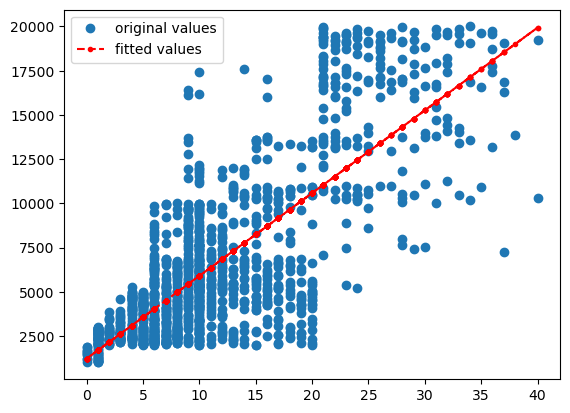

In [5]:
#Scatter plot

plt.plot(df['TotalWorkingYears'], df['MonthlyIncome'], 'o', label='original values')
plt.plot(df['TotalWorkingYears'], model.fittedvalues, 'r--.', label='fitted values')
plt.legend()
plt.show()

#### The results of the OLS regression analysis show a clear and statistically significant positive relationship between (TotalWorkingYears) and (MonthlyIncome). The extremely low p-value strongly suggests rejecting the null hypothesis and confirming a substantial connection. The model results show approximately an R-squared value of 0.597 in monthly wages based on years of work experience,  This indicates a good model fit. The positive tendency is consistent with the widely held layman belief that gaining job experience may lead to increased earnings as skills and knowledge improve over time.

# Q2

In [6]:
#OLS
model = ols('DistanceFromHome ~ Age', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       DistanceFromHome   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                  0.004174
Date:                Mon, 30 Oct 2023   Prob (F-statistic):              0.948
Time:                        23:58:39   Log-Likelihood:                -5161.6
No. Observations:                1470   AIC:                         1.033e+04
Df Residuals:                    1468   BIC:                         1.034e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.2478      0.881     10.497      0.0

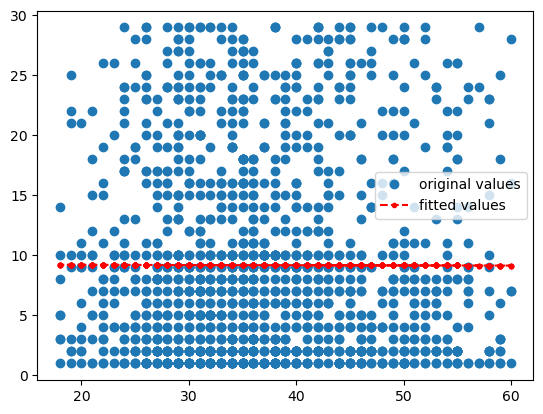

In [8]:
#Scatter plot with regression line

plt.plot(df['Age'], df['DistanceFromHome'], 'o', label='original values')
plt.plot(df['Age'], model.fittedvalues, 'r--.', label='fitted values')
plt.legend()
plt.show()

#### The R-squared value is clearly 0.000, showing that the model does not explain any variation in DistanceFromHome based on Age. This means that there is no direct association between an employee's age and their commute time. A scatter plot with a regression line, as plotted visually confirms the dispersed and far away nature of the data points. P-value of supports this result, revealing no statistical significance. 


# Q3

In [135]:
#Correlation
print("Correlation between TotalWorkingYears and MonthlyIncome")
print(df['TotalWorkingYears'].corr(df['MonthlyIncome']))

Correlation between TotalWorkingYears and MonthlyIncome
0.7728932462543562


In [136]:
print("Correlation between Age and DistanceFromHome")
print(df['Age'].corr(df['DistanceFromHome']))

Correlation between Age and DistanceFromHome
-0.0016861201480870226


#### The correlation coefficient is found to be 0.77. This shows a hugely positive association between the two variables. On the other hand, the connection between Age and DistanceFromHome, the correlation coefficient is calculated to be -0.0016, which is an extremely weak + negative relationship. This suggests that an employee’s age has literally no impact on their distance from home.

# Q4

In [20]:
#Regression
categorical=df.select_dtypes(exclude=['int','float']).columns.tolist()
dff = pd.get_dummies(df, columns=[x for x in categorical])
X,Y = dff.drop(['MonthlyIncome'], axis=1), dff['MonthlyIncome']
model4=sm.OLS(Y, sm.add_constant(X)).fit()
model4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          MonthlyIncome   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     715.9
Date:                Tue, 31 Oct 2023   Prob (F-statistic):               0.00
Time:                        01:01:56   Log-Likelihood:                -12394.
No. Observations:                1470   AIC:                         2.486e+04
Df Residuals:                    1435   BIC:                         2.504e+04
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                               364.2019    129.213      2.819      0.005     110.735     617.669
Age                                  -5.3357      4.614     -1.156      0.248     -14.386       3.715
DistanceFromHome                     -4.8212      3.650     -1.321      0.187     -11.981       2.339
Education                           -11.1578     29.743     -0.375      0.708     -69.502      47.186
HourlyRate                            1.3410      1.454      0.923      0.356      -1.511       4.193
JobLevel                           2759.6363     67.718     40.752      0.000    2626.800    2892.473
NumCompaniesWorked                   11.5087     13.246      0.869      0.385     -14.475      37.493
PerformanceRating                   -29.6861     81.840     -0.363      0.717    -190.225     130.853
StockOptionLevel                    -42.3557     47.499     -0.892      0.373    -135.530      50.818
TotalWorkingYears                    48.0088      8.316      5.773      0.000      31.696      64.321
TrainingTimesLastYear               -16.7479     23.135     -0.724      0.469     -62.130      28.634
WorkLifeBalance                     -22.7978     42.025     -0.542      0.588    -105.235      59.640
YearsAtCompany                        6.6563     10.392      0.641      0.522     -13.729      27.041
YearsInCurrentRole                    1.2712     13.482      0.094      0.925     -25.175      27.717
YearsSinceLastPromotion              23.3883     11.880      1.969      0.049       0.084      46.693
YearsWithCurrManager                -34.1053     13.789     -2.473      0.013     -61.154      -7.057
Department_Human Resources            9.7448    276.725      0.035      0.972    -533.084     552.574
Department_Research & Development   257.1010    170.358      1.509      0.131     -77.077     591.279
Department_Sales                     97.3561    186.808      0.521      0.602    -269.090     463.802
EducationField_Human Resources      114.4753    242.487      0.472      0.637    -361.192     590.143
EducationField_Life Sciences         38.6894     72.369      0.535      0.593    -103.270     180.649
EducationField_Marketing            104.4560    110.500      0.945      0.345    -112.303     321.215
EducationField_Medical               28.7257     76.079      0.378      0.706    -120.513     177.964
EducationField_Other                -46.9271    120.714     -0.389      0.698    -283.722     189.868
EducationField_Technical Degree     124.7826    102.199      1.221      0.222     -75.692     325.257
Gender_Female                       139.3035     72.290      1.927      0.054      -2.501     281.108
Gender_Male                         224.8984     70.391      3.195      0.001      86.818     362.979
JobRole_Healthcare Repr

#### In the regression model predicting MonthlyIncome, p-values guide us to discern the strength of each variable's influence.

### Maximum Influencers:
#### JobLevel, TotalWorkingYears, and specific job roles stand out as the most influential factors, each with a p-value of 0.0, underscoring their substantial impact on determining monthly earnings. P-value <0.05 = strong relationship.

### Minimal Influencers:
#### On the other hand we have, PerformanceRating, YearsInCurrentRole, and WorkLifeBalance exhibit the highest p-values, marking them as the least impactful on MonthlyIncome.








In [21]:
# Defining new data to predict MonthlyIncome
new_data = pd.DataFrame({
    'Age': [35],
    'Department': ['Sales'],
    'DistanceFromHome': [10],
    'Education': [4],
    'EducationField': ['Marketing'],
    'Gender': ['Female'],
    'HourlyRate': [60],
    'JobLevel': [3],
    'JobRole': ['Sales Executive'],
    'MaritalStatus': ['Married'],
    'NumCompaniesWorked': [3],
    'OverTime': ['Yes'],
    'PerformanceRating': [4],
    'StockOptionLevel': [2],
    'TotalWorkingYears': [15],
    'TrainingTimesLastYear': [5],
    'WorkLifeBalance': [4],
    'YearsAtCompany': [7],
    'YearsInCurrentRole': [5],
    'YearsSinceLastPromotion': [2],
    'YearsWithCurrManager': [3]
})

#Merging the new data with the existing dataset and ignoring index
concatenated_data = pd.concat([df, new_data], ignore_index=True)

#Dropping the target variable 'MonthlyIncome' from the dataset
concatenated_data = concatenated_data.drop(['MonthlyIncome'], axis=1)

#Converting categorical variables into dummy/indicator variables
concatenated_data_dummy_encoded = pd.get_dummies(concatenated_data, columns=categorical)

#Adding a constant to the model (intercept)
concatenated_data_dummy_encoded = sm.add_constant(concatenated_data_dummy_encoded)

#Selecting the last row (new data) for prediction
data_to_predict = concatenated_data_dummy_encoded.tail(1)

#Printing the predicted MonthlyIncome
print("The predicted MonthlyIncome is: ")
print(model4.predict(data_to_predict))


The predicted MonthlyIncome is: 
1470    8937.71653
dtype: float64


#### Here is the prediction:

# Q5

In [22]:

df5 = pd.get_dummies(df, columns=[x for x in categorical])
X = df5.drop(['HourlyRate'], axis=1)
Y = df5['HourlyRate']
model5 = sm.OLS(Y, sm.add_constant(X)).fit()
model5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             HourlyRate   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.6846
Date:                Tue, 31 Oct 2023   Prob (F-statistic):              0.916
Time:                        01:02:18   Log-Likelihood:                -6501.3
No. Observations:                1470   AIC:                         1.307e+04
Df Residuals:                    1435   BIC:                         1.326e+04
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                21.8033      2.281      9.560      0.000      17.329      26.277
Age                                   0.0632      0.084      0.754      0.451      -0.101       0.228
DistanceFromHome                      0.0797      0.066      1.203      0.229      -0.050       0.210
Education                             0.2087      0.540      0.386      0.699      -0.851       1.268
JobLevel                             -3.1841      1.804     -1.765      0.078      -6.722       0.354
NumCompaniesWorked                    0.1083      0.241      0.450      0.653      -0.364       0.580
PerformanceRating                    -0.3151      1.486     -0.212      0.832      -3.230       2.599
StockOptionLevel                      1.4108      0.862      1.637      0.102      -0.280       3.101
TotalWorkingYears                     0.0492      0.153      0.322      0.747      -0.250       0.349
TrainingTimesLastYear                -0.0827      0.420     -0.197      0.844      -0.907       0.741
WorkLifeBalance                       0.1144      0.763      0.150      0.881      -1.382       1.611
YearsAtCompany                        0.0478      0.189      0.253      0.800      -0.322       0.418
YearsInCurrentRole                   -0.1133      0.245     -0.463      0.643      -0.593       0.367
YearsSinceLastPromotion              -0.1686      0.216     -0.781      0.435      -0.592       0.255
YearsWithCurrManager                 -0.0090      0.251     -0.036      0.972      -0.501       0.483
MonthlyIncome                         0.0004      0.000      0.923      0.356      -0.000       0.001
Department_Human Resources            7.7458      5.020      1.543      0.123      -2.101      17.592
Department_Research & Development     6.3040      3.091      2.040      0.042       0.241      12.367
Department_Sales                      7.7535      3.386      2.290      0.022       1.112      14.395
EducationField_Human Resources       -1.5980      4.402     -0.363      0.717     -10.234       7.038
EducationField_Life Sciences          5.9413      1.305      4.554      0.000       3.382       8.500
EducationField_Marketing              5.6866      2.001      2.842      0.005       1.761       9.612
EducationField_Medical                4.2543      1.377      3.090      0.002       1.554       6.955
EducationField_Other                  1.6687      2.191      0.762      0.446      -2.630       5.967
EducationField_Technical Degree       5.8505      1.850      3.163      0.002       2.222       9.479
Gender_Female                        10.9132      1.282      8.512      0.000       8.398      13.428
Gender_Male                          10.8901      1.250      8.713      0.000       8.438      13.342
JobRole_Healthcare Repr

#### p_value >0.05 = weak

#### Most influential inputs: Department, Gender, and OverTime are the most influential inputs. Their p-values are the lowest (0.0),

#### Least influential inputs: are the three variables with the highest p-values. Therefore, YearsWithCurrManager, WorkLifeBalance, and YearsAtCompany are the least influential inputs. their influence is negligible.

In [27]:
new_data2 = pd.DataFrame({
    'Age': [35],
    'Department': ['Sales'],
    'DistanceFromHome': [10],
    'Education': [4],
    'EducationField': ['Marketing'],
    'Gender': ['Female'],
    'JobLevel': [3],
    'JobRole': ['Sales Executive'],
    'MaritalStatus': ['Married'],
    'NumCompaniesWorked': [3],
    'OverTime': ['Yes'],
    'PerformanceRating': [4],
    'StockOptionLevel': [2],
    'TotalWorkingYears': [15],
    'TrainingTimesLastYear': [5],
    'WorkLifeBalance': [4],
    'YearsAtCompany': [7],
    'YearsInCurrentRole': [5],
    'YearsSinceLastPromotion': [2],
    'YearsWithCurrManager': [3],
    'MonthlyIncome': [5000]
})

#Concate
new_data2 = pd.concat([df, new_data2], ignore_index=True)
#drop HourlyRate Column
new_data2 = new_data2.drop(['HourlyRate'], axis=1)
#get dummies
df5 = pd.get_dummies(new_data2, columns=[x for x in categorical])
df5 = sm.add_constant(df5)
#predict
new_data2 = df5.tail(1)
print("The predicted HourlyRate is: ")
print(model5.predict(new_data2))

The predicted HourlyRate is: 
1470    64.802197
dtype: float64


#### The predicted hourly rate is 64.8

# Q6

In [28]:
df6 = dff[["JobLevel", "TotalWorkingYears", "JobRole_Healthcare Representative", "JobRole_Human Resources", "JobRole_Laboratory Technician", "JobRole_Manager", "JobRole_Manufacturing Director", "JobRole_Research Director", "JobRole_Research Scientist", "JobRole_Sales Executive", "JobRole_Sales Representative"]]
X = df6
Y = dff['MonthlyIncome']
model6 = sm.OLS(Y, sm.add_constant(X)).fit()
model6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          MonthlyIncome   R-squared:                       0.943
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     2434.
Date:                Tue, 31 Oct 2023   Prob (F-statistic):               0.00
Time:                        01:14:34   Log-Likelihood:                -12406.
No. Observations:                1470   AIC:                         2.483e+04
Df Residuals:                    1459   BIC:                         2.489e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                               650.7952    115.041      5.657      0.000     425.131     876.459
JobLevel                           2770.3438     66.712     41.527      0.000    2639.481    2901.206
TotalWorkingYears                    43.7428      6.243      7.007      0.000      31.496      55.989
JobRole_Healthcare Representative  -589.2785     95.948     -6.142      0.000    -777.490    -401.067
JobRole_Human Resources            -874.7981    146.171     -5.985      0.000   -1161.526    -588.071
JobRole_Laboratory Technician     -1182.0511     83.040    -14.235      0.000   -1344.942   -1019.160
JobRole_Manager                    3533.6967    159.597     22.141      0.000    3220.633    3846.760
JobRole_Manufacturing Director     -697.5272     91.850     -7.594      0.000    -877.699    -517.356
JobRole_Research Director          3434.5429    156.134     21.997      0.000    3128.273    3740.813
JobRole_Research Scientist        -1078.4361     81.698    -13.200      0.000   -1238.695    -918.177
JobRole_Sales Executive            -662.0867     66.629     -9.937      0.000    -792.786    -531.388
JobRole_Sales Representative      -1233.2667    125.934     -9.793      0.000   -1480.298    -986.236
==============================================================================
Omnibus:                       45.881   Durbin-Watson:                   2.060
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               89.325
Skew:                           0.204   Prob(JB):                     4.01e-20
Kurtosis:                       4.137   Cond. No.                     3.94e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.83e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

#### This model performed well, outperforming the model in question 4. The R-squared result is surprisingly high at 0.943, indicating that differences in TotalWorkingYears and diverse JobRoles account for 94.3% of the variance in MonthlyIncome. This high R-squared value emphasises the model's strong data fit. Surprisingly, the model achieves this high explanatory power with only three variables, demonstrating its effectiveness. The fact that the p-values for all of the inputs are nearly 0.000 reinforces the case for a strong and significant link between the specified predictors and MonthlyIncome. 


# Q7

In [30]:
entry1 = pd.DataFrame({
    'Age': [35],
    'Department': ['Research & Development'],
    'DistanceFromHome': [10],
    'Education': [4],
    'EducationField': ['Life Sciences'],
    'Gender': ['Female'],
    'HourlyRate': [50],
    'JobLevel': [2],
    "JobRole_Healthcare Representative": [0],
    "JobRole_Human Resources" : [0],
    "JobRole_Laboratory Technician" : [0],
    "JobRole_Manager" : [0],
    "JobRole_Manufacturing Director" : [1],
    "JobRole_Research Director" : [0],
    "JobRole_Research Scientist" : [0],
    "JobRole_Sales Executive" : [0],
    "JobRole_Sales Representative" : [0],
    'MaritalStatus': ['single'],
    'NumCompaniesWorked': [5],
    'OverTime': ['No'],
    'PerformanceRating': [2],
    'StockOptionLevel': [2],
    'TotalWorkingYears': [20],
    'TrainingTimesLastYear': [2],
    'WorkLifeBalance': [2],
    'YearsAtCompany': [11],
    'YearsInCurrentRole': [2],
    'YearsSinceLastPromotion': [2],
    'YearsWithCurrManager': [4]
})

entry2 = pd.DataFrame({
    'Age' : [20],
    'Department' : ['Research & Development'],
    'DistanceFromHome' : [10],
    'Education' : [3],
    'EducationField' : ['Marketing'],
    'Gender': ['Male'],
    'HourlyRate': [70],
    'JobLevel': [3],
    "JobRole_Healthcare Representative": [0],
    "JobRole_Human Resources" : [0],
    "JobRole_Laboratory Technician" : [0],
    "JobRole_Manager" : [0],
    "JobRole_Manufacturing Director" : [0],
    "JobRole_Research Director" : [0],
    "JobRole_Research Scientist" : [1],
    "JobRole_Sales Executive" : [0],
    "JobRole_Sales Representative" : [0],
    'MaritalStatus': ['Married'],
    'NumCompaniesWorked': [1],
    'OverTime': ['Yes'],
    'PerformanceRating': [1],
    'StockOptionLevel': [0],
    'TotalWorkingYears': [7],
    'TrainingTimesLastYear': [1],
    'WorkLifeBalance': [3],
    'YearsAtCompany': [10],
    'YearsInCurrentRole': [5],
    'YearsSinceLastPromotion': [1],
    'YearsWithCurrManager': [5],
})

#Concate
X = pd.concat([df, entry1, entry2], ignore_index=True)
#drop MonthlyIncome Column
X = X.drop(['MonthlyIncome'], axis=1)

X = X[["JobLevel", "TotalWorkingYears", "JobRole_Healthcare Representative", 
       "JobRole_Human Resources", "JobRole_Laboratory Technician", "JobRole_Manager", 
       "JobRole_Manufacturing Director", "JobRole_Research Director", "JobRole_Research Scientist", 
       "JobRole_Sales Executive", "JobRole_Sales Representative"]]

X = sm.add_constant(X, has_constant='add')

print(model6.predict(X.tail(2)))


1470    6368.810989
1471    8189.589900
dtype: float64


#### The first entry's predicted monthly income appears to be fairly low for a Manufacturing Director with 20 years of experience, implying potential missing elements/context in the model. In contrast, the expected pay for the second entry corresponds to that of a Research Scientist at employment level 3 with 7 years of experience. The model, with an adjusted R-squared of 0.943, makes reliable predictions.
